# Coupled furnace-tube model: Latham (2008) plant cases, baseline

Long-furnace (plug-flow furnace gas) model `rdt.furnace` coupled to the 1-D tube model, run for the four
Latham thesis cases (Appendix H) with Latham et al. (2011) Table 6 values as starting parameters and **no
fitting**: L_q 0.48, alpha_top 0.182, f_htg 1.68 (Leva-Grummer), voidage 0.607, activity 0.20, eta 0.1 with
0.05 in the top section, f_ctube 0.38; geometry OD 0.146 m, wall 15 mm (assumed), heated 12.5 m,
lambda_tube 29.6 W/(m K), d_p 5.40 mm, rho_bed 1100 kg/m3; exchange factor F_gt = 0.35 (initial guess).
Measured tube-wall temperatures are absolute (thesis), with 95 % CI bars = 1.96 x the thesis Table 15 uncertainty (3 K).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

from rdt import latham_cases as lc

df = lc.load_cases()
print(df[["case", "plant_rate_pct", "T_in_K", "P_in_Pa", "feed_per_tube_kmol_h", "steam_to_carbon_derived",
          "heat_of_combustion_LHV_W_derived", "flue_gas_kmol_h_derived", "excess_air_pct_derived", "T_fg_mixed_inlet_K_derived"]].round(3).to_string())
p = lc.BASELINE
print("\nbaseline parameters:", p)
runs = lc.run_all(p)
tab = lc.summary_table(runs)
pd.set_option("display.width", 250)
cols = ["rate_pct", "out_T_K_pred", "out_T_K_meas", "out_T_K_diff", "out_P_Pa_pred", "out_P_Pa_meas", "out_P_Pa_diff",
        "out_x_H2_wet_molpct_pred", "out_x_H2_wet_molpct_meas", "out_x_CH4_wet_molpct_pred", "out_x_CH4_wet_molpct_meas",
        "flue_out_T_K_pred", "flue_out_T_K_meas", "flue_out_T_K_diff", "TWT_upper_K_pred", "TWT_upper_K_meas", "TWT_upper_K_diff",
        "TWT_lower_K_pred", "TWT_lower_K_meas", "TWT_lower_K_diff", "TWT_peak_frac", "TWT_peak_K", "T_fg_max_K", "energy_closure"]
print("\n" + tab[cols].round(3).T.to_string())
for case, d in runs.items():
    print(f"{case}: runtime {d['result'].wall_time_s:.2f} s, RHS evals {d['result'].n_rhs_evals}, success {d['result'].success}")


       case  plant_rate_pct  T_in_K    P_in_Pa  feed_per_tube_kmol_h  steam_to_carbon_derived  heat_of_combustion_LHV_W_derived  flue_gas_kmol_h_derived  excess_air_pct_derived  T_fg_mixed_inlet_K_derived
0   Plant_A              99  884.55  3006000.0                23.470                    2.892                      2.189969e+08                13260.512                  21.641                     524.693
1   Plant_B              92  887.05  2944000.0                21.051                    2.794                      2.033938e+08                12820.158                  25.432                     520.929
2  Plant_C1              96  890.95  3026700.0                28.732                    2.849                      2.032193e+08                11933.539                  17.414                     527.948
3  Plant_C2              71  879.85  2808500.0                15.938                    2.858                      1.462777e+08                 9090.983                  23.554    


case                           Plant_A      Plant_B     Plant_C1     Plant_C2
rate_pct                        99.000       92.000       96.000       71.000
out_T_K_pred                  1109.169     1109.183     1062.677     1112.509
out_T_K_meas                  1105.550     1107.150     1122.050     1108.950
out_T_K_diff                     3.619        2.033      -59.373        3.559
out_P_Pa_pred              2838699.181  2806886.305  2788174.415  2724674.198
out_P_Pa_meas              2846100.000  2804000.000  2879800.000  2723400.000
out_P_Pa_diff                -7400.819     2886.305   -91625.585     1274.198
out_x_H2_wet_molpct_pred        45.851       46.306       41.754       46.823
out_x_H2_wet_molpct_meas        45.825       46.313       47.132       46.551
out_x_CH4_wet_molpct_pred        5.104        5.330        7.609        4.748
out_x_CH4_wet_molpct_meas        5.046        5.260        4.536        4.823
flue_out_T_K_pred             1294.972     1282.010     1255.38

saved /Users/izbassar/Documents/Projects/reformer-digital-twin/paper/figures/fig04_latham_baseline.png


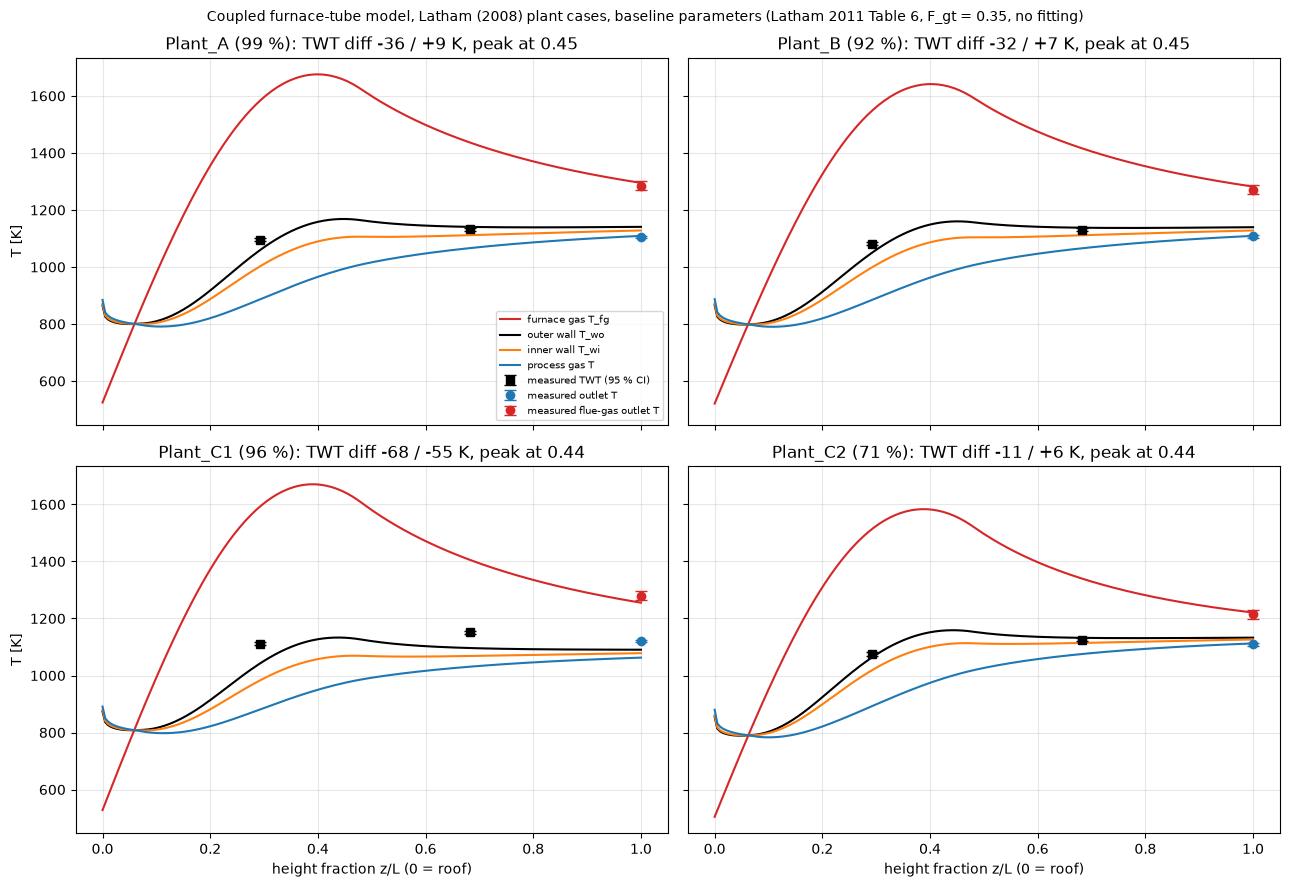

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True, sharey=True)
for ax, (case, d) in zip(axes.ravel(), runs.items()):
    res = d["result"]; row = df[df.case == case].iloc[0]; zf = res.z_frac
    ax.plot(zf, res.T_fg, color="C3", label="furnace gas T_fg")
    ax.plot(zf, res.T_wo, color="k", label="outer wall T_wo")
    ax.plot(zf, res.T_wi, color="C1", label="inner wall T_wi")
    ax.plot(zf, res.tube.T, color="C0", label="process gas T")
    ci = 1.96 * row.sigma_TWT_K
    ax.errorbar([row.TWT_upper_frac, row.TWT_lower_frac], [row.TWT_upper_K, row.TWT_lower_K], yerr=ci, fmt="s", color="k", ms=6, capsize=4, label="measured TWT (95 % CI)")
    ax.errorbar([1.0], [row.out_T_K], yerr=1.96 * row.sigma_out_T_K, fmt="o", color="C0", ms=6, capsize=4, label="measured outlet T")
    ax.errorbar([1.0], [row.flue_out_T_K], yerr=1.96 * row.sigma_flue_out_T_K, fmt="o", color="C3", ms=6, capsize=4, label="measured flue-gas outlet T")
    c = d["comparison"]
    ax.set_title(f"{case} ({d['plant_rate_pct']} %): TWT diff {c['TWT_upper_K']['difference']:+.0f} / {c['TWT_lower_K']['difference']:+.0f} K, peak at {c['TWT_peak']['z_frac']:.2f}")
    ax.grid(alpha=0.3)
axes[0, 0].legend(fontsize=7, loc="lower right")
for ax in axes[1]: ax.set_xlabel("height fraction z/L (0 = roof)")
for ax in axes[:, 0]: ax.set_ylabel("T [K]")
fig.suptitle("Coupled furnace-tube model, Latham (2008) plant cases, baseline parameters (Latham 2011 Table 6, F_gt = 0.35, no fitting)", fontsize=10)
fig.tight_layout()
out = Path("..") / "paper" / "figures" / "fig04_latham_baseline.png"
fig.savefig(out, dpi=150); print("saved", out.resolve()); plt.show()


In [3]:
def py(o):
    if isinstance(o, dict): return {str(k): py(v) for k, v in o.items() if k != "result"}
    if isinstance(o, (list, tuple)): return [py(v) for v in o]
    if isinstance(o, (np.floating, np.integer)): return o.item()
    if isinstance(o, np.bool_): return bool(o)
    return o
from dataclasses import asdict
doc = {
    "source": "Latham (2008) thesis Appendix H plant cases; parameters Latham et al. (2011) Table 6",
    "data_file": "data/literature_validation/latham2008_plant_cases.csv",
    "model": "rdt.furnace.simulate_coupled: plug-flow furnace gas, parabolic heat release (L_q, alpha_top), q = sigma F_gt (T_fg^4 - T_wo^4) + h_conv (T_fg - T_wo); tube: rdt.reactor1d (Xu-Froment kinetics, Leva-Grummer x f_htg, Ergun)",
    "baseline": {
        "parameters": asdict(p),
        "assumptions": ["wall thickness 15 mm (ID 0.116 m) not given by Latham", "F_gt = 0.35 initial guess",
                        "furnace plan dimensions assumed for the convective term only (rdt.furnace.LATHAM_FURNACE)",
                        "heat of combustion, flue-gas flow, excess air derived from thesis Table 29 streams (LHV basis)",
                        "furnace gas enters at the mixed fuel/air temperature; ordering T_gas < T_wi < T_wo < T_fg holds for z >= L/15"],
        "cases": py({k: {"plant_rate_pct": v["plant_rate_pct"], **v["comparison"]} for k, v in runs.items()}),
        "summary_table": py(tab.reset_index().to_dict(orient="records")),
    },
}
with open(Path("..") / "data" / "literature_validation" / "latham_fit.yaml", "w") as f:
    yaml.safe_dump(doc, f, sort_keys=False, default_flow_style=False, width=130)
print("wrote latham_fit.yaml")


wrote latham_fit.yaml
